In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
import math
import random
from random import uniform
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Exercice 1 : Binary classification using logistic regression

## Load data and inspection of the data

In [5]:
# We will load the data that is in the file 'donnees_exo1.txt'
data = pd.read_csv('donnees_exo1.txt', sep = ' ')

In [6]:
data

,X1,X2,Y
0,-0.697580,0.684940,0
1,-0.478690,0.633770,1
2,0.057028,0.918860,0
3,-0.593890,0.494880,0
4,0.229840,-0.411550,1
...,...,...,...
113,0.460250,0.012427,1
114,-0.046659,0.816520,1
115,0.322000,0.692250,1
116,-0.524770,0.209800,1


In [7]:
print("Number of examples:", data.shape[0])
print("Number of features:", data.shape[1] - 1)  # X1 and X2; Y is the target
print("Target distribution:")
print(data.Y.value_counts())

# 118 examples, 2 features, almost balanced target: 60 class 0 and 58 class 1.

Number of examples: 118
Number of features: 2
Target distribution:
Y
0    60
1    58
Name: count, dtype: int64


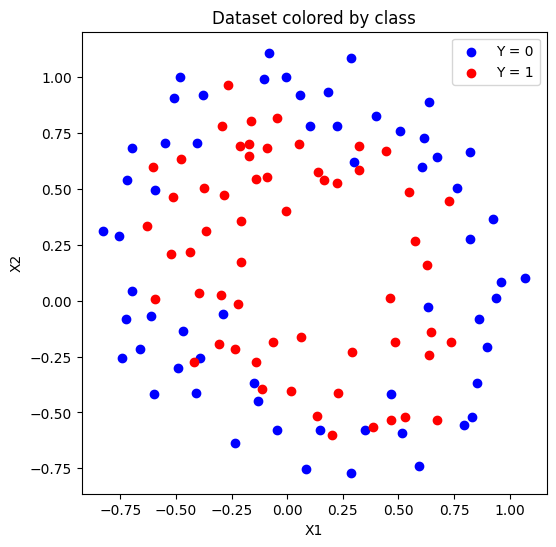

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(data.X1[data.Y == 0], data.X2[data.Y == 0], c="blue", label="Y = 0")
plt.scatter(data.X1[data.Y == 1], data.X2[data.Y == 1], c="red", label="Y = 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Dataset colored by class")
plt.show()

## Train / Validation / Test split

In [9]:
# 70% train, then split the remaining 30% in half -> 15% validation and 15% test
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, stratify=data.Y)
val_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=temp_data.Y)
print("train:", train_data.shape, "val:", val_data.shape, "test:", test_data.shape)

train: (82, 3) val: (18, 3) test: (18, 3)


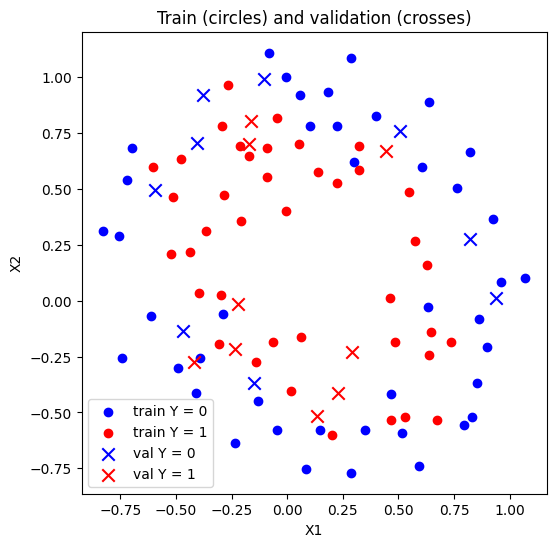

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(train_data.X1[train_data.Y == 0], train_data.X2[train_data.Y == 0],
            c="blue", marker="o", label="train Y = 0")
plt.scatter(train_data.X1[train_data.Y == 1], train_data.X2[train_data.Y == 1],
            c="red", marker="o", label="train Y = 1")
plt.scatter(val_data.X1[val_data.Y == 0], val_data.X2[val_data.Y == 0],
            c="blue", marker="x", s=80, label="val Y = 0")
plt.scatter(val_data.X1[val_data.Y == 1], val_data.X2[val_data.Y == 1],
            c="red", marker="x", s=80, label="val Y = 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Train (circles) and validation (crosses)")
plt.show()

## Fitting a logistic regression model

In [11]:
lr_model = LogisticRegression().fit(train_data.iloc[:,0:2], train_data.Y)
# Parameters can be added to the 'LogisticRegression' call (we will see this later when we'll need)
# 2 parameters are given to the 'fit' function : 
#  - a dataset containing the features of the examples (here X1 and X2, the 2 first columns of the training set)
#  - a vector containing the labels (Y) of the examples (in the same order), 0 or 1 here

In [12]:
# 3 parameters: intercept theta_0, plus one weight for X1 and one for X2.
print("n_parameters =", 1 + lr_model.coef_.shape[1])

n_parameters = 3


In [13]:
lr_model.intercept_

array([-0.04103162])

In [14]:
lr_model.coef_

array([[-0.47013621,  0.319003  ]])

In [15]:
x1 = train_data.iloc[0, 0]
x2 = train_data.iloc[0, 1]
theta0 = lr_model.intercept_[0]
theta1, theta2 = lr_model.coef_[0]
z = theta0 + theta1 * x1 + theta2 * x2
h = 1 / (1 + math.exp(-z))  # P(Y = 1 | X)
print("X1, X2 =", x1, x2)
print("z =", z)
print("h_theta(x) = P(Y=1|X) =", h)

X1, X2 = -0.0063364 0.99927
z = 0.2807174868873241
h_theta(x) = P(Y=1|X) = 0.5697221166242173


In [16]:
decision = 1 if h >= 0.5 else 0
print("Decision:", decision)
print("Because P(Y=1|X) is", ">=" if h >= 0.5 else "<", "0.5")
print("True label:", train_data.iloc[0].Y)
print("Correct decision?", decision == train_data.iloc[0].Y)

Decision: 1
Because P(Y=1|X) is >= 0.5
True label: 0.0
Correct decision? False


In [17]:
lr_model.predict_proba(train_data.iloc[0:1,0:2])
# actually this command gives you the two probabilities : P(Y = 0 | X1, X2) and P(Y = 1 | X1, X2)
# You should obtain the same probability than the one calculated above

array([[0.43027788, 0.56972212]])

In [18]:
# The final decision of the model can be obtained by the command:
lr_model.predict(train_data.iloc[0:1,0:2])

array([1])

In [19]:
lr_model.score(train_data.iloc[:,0:2], train_data.Y)

0.5609756097560976

In [20]:
print("Validation accuracy:", lr_model.score(val_data.iloc[:, 0:2], val_data.Y))

Validation accuracy: 0.5


## Visualization of the decision boundary

In [21]:
def draw_boundary(model, data, deg, x_min, x_max, y_min, y_max):
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    zz = np.c_[xx.ravel(), yy.ravel()]
    zz = pd.DataFrame(zz)
    if(deg>1):
        poly = PolynomialFeatures(degree=deg, include_bias=False)
        zz2 = poly.fit_transform(zz)
        zz2 = pd.DataFrame(zz2)
    else:
        zz2 = zz
    pred_zz= pd.Series(model.predict(zz2))
    color_map = matplotlib.colors.ListedColormap(pd.Series(['blue', 'red']))
    fig = plt.figure(figsize=  (8,8))
    fig = plt.scatter(zz.iloc[:,0], zz.iloc[:,1], c = pred_zz, cmap = color_map, marker='+')
    fig = plt.scatter(data.iloc[:,0], data.iloc[:,1], s = 50, c = data.iloc[:,2], cmap = color_map)
    

/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


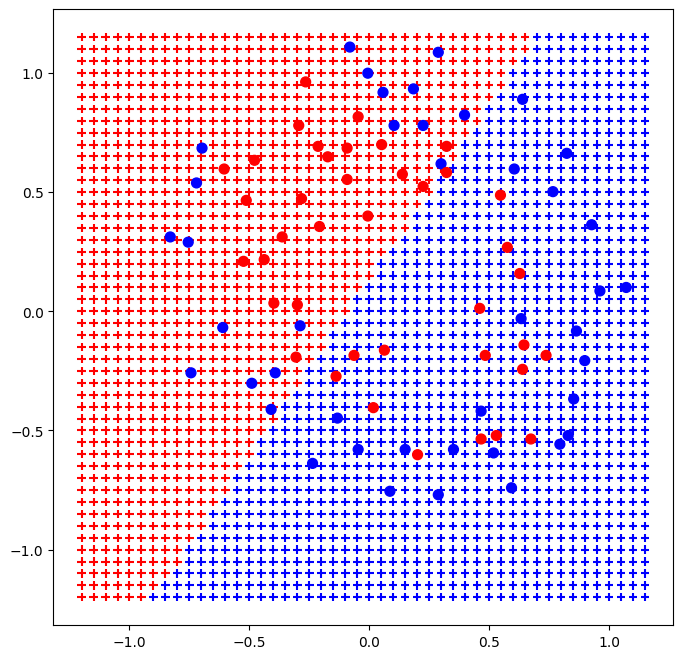

In [22]:
draw_boundary(lr_model, train_data, 1, -1.2, 1.2, -1.2, 1.2)

In [23]:
# We will now see how to add polynomial features to the dataset before fitting a logistic regression model:

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=False) # LogisticRegression already fits the intercept.
# The degree of the features can be modified in the parameters
X_train2 = poly.fit_transform(train_data.iloc[:,0:2]) # Here we use the 'poly' created above to add polynomial
# features of degree 2 to the training set
# It adds three columns: X1^2, X1*X2 and X2^2.

In [25]:
print(X_train2.shape)
# n_train rows and 5 columns: X1, X2, X1^2, X1*X2, X2^2

(82, 5)


In [26]:
lr_model2 = LogisticRegression().fit(X_train2, train_data.Y)


In [27]:
print("Train accuracy (degree 2):", lr_model2.score(X_train2, train_data.Y))
print("Train accuracy (degree 1):", lr_model.score(train_data.iloc[:, 0:2], train_data.Y))
# Yes: the degree-2 model is much better (the data are not linearly separable).

Train accuracy (degree 2): 0.7926829268292683
Train accuracy (degree 1): 0.5609756097560976


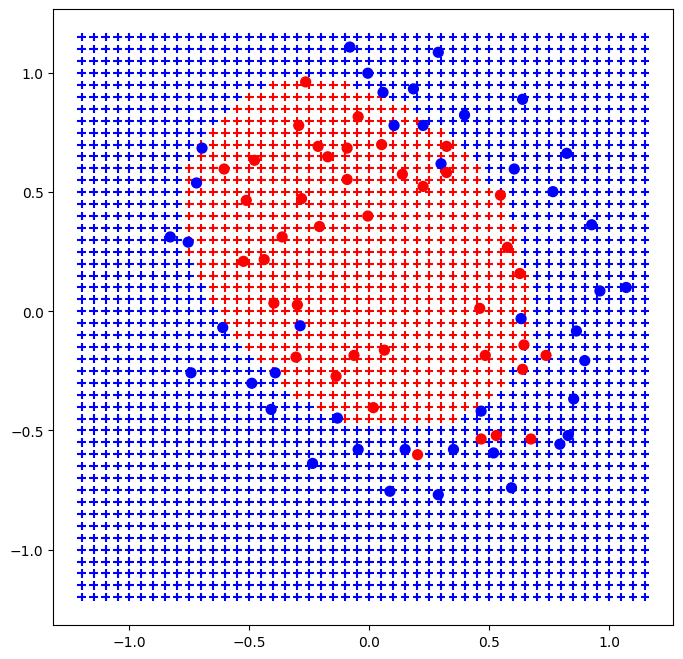

In [28]:
draw_boundary(lr_model2, train_data, 2, -1.2, 1.2, -1.2, 1.2)

In [29]:
X_val2 = poly.transform(val_data.iloc[:, 0:2])
print("Validation accuracy (degree 2):", lr_model2.score(X_val2, val_data.Y))

Validation accuracy (degree 2): 0.5555555555555556


In [30]:
# Model selection: train on the training set, choose the degree with the best validation accuracy,
# then estimate the generalization error once on the held-out test set.
results = []
saved = {}
for deg in range(1, 7):
    poly_d = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr = poly_d.fit_transform(train_data.iloc[:, 0:2])
    X_va = poly_d.transform(val_data.iloc[:, 0:2])
    model_d = LogisticRegression(max_iter=1000).fit(X_tr, train_data.Y)
    acc_tr = model_d.score(X_tr, train_data.Y)
    acc_va = model_d.score(X_va, val_data.Y)
    results.append((deg, X_tr.shape[1], acc_tr, acc_va))
    saved[deg] = (model_d, poly_d)
    print(f"degree={deg}  n_features={X_tr.shape[1]:2d}  train={acc_tr:.4f}  val={acc_va:.4f}")

# Highest validation accuracy; if tie, keep the smallest degree
best_deg = max(results, key=lambda r: (r[3], -r[0]))[0]
print("Selected degree:", best_deg)

best_model, best_poly = saved[best_deg]
X_te = best_poly.transform(test_data.iloc[:, 0:2])
gen_acc = best_model.score(X_te, test_data.Y)
print("Test accuracy (generalization estimate):", gen_acc)
print("Estimated generalization error:", 1 - gen_acc)

degree=1  n_features= 2  train=0.5610  val=0.5000
degree=2  n_features= 5  train=0.7927  val=0.5556
degree=3  n_features= 9  train=0.8049  val=0.5556
degree=4  n_features=14  train=0.8049  val=0.7222
degree=5  n_features=20  train=0.8049  val=0.6111
degree=6  n_features=27  train=0.8049  val=0.6667
Selected degree: 4
Test accuracy (generalization estimate): 0.8333333333333334
Estimated generalization error: 0.16666666666666663


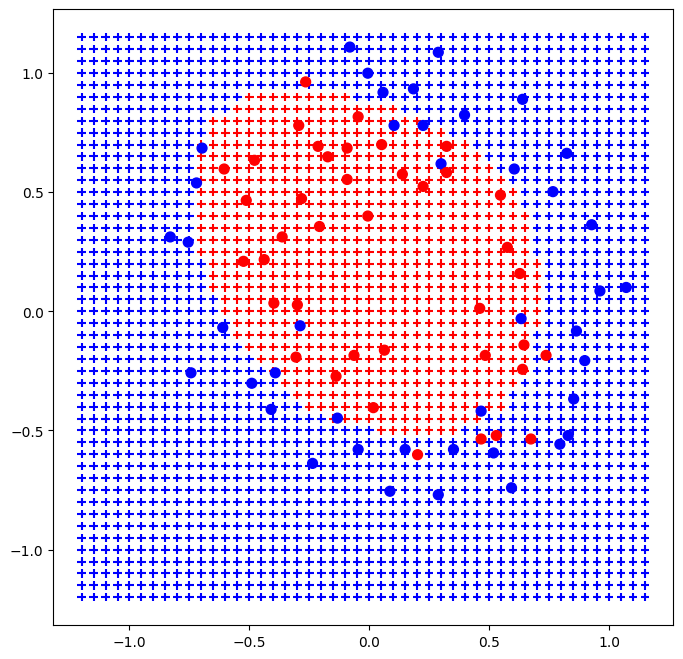

In [31]:
# Do not compare another degree on the test set: it must remain a single final evaluation.
# The selected degree is the smallest degree tied for the highest validation accuracy.
draw_boundary(best_model, train_data, best_deg, -1.2, 1.2, -1.2, 1.2)

#  Exercice 2 : Multi-class classification

In [32]:
# Load the data. 
segment = pd.read_csv("segment.txt", sep = ' ')
segment

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,y
0,218,178,9,0.111111,0.0,0.833333,0.547722,1.111109,0.544331,59.629630,52.444443,75.222220,51.222220,-21.555555,46.777780,-25.222221,75.222220,0.318996,-2.040554,6
1,113,130,9,0.000000,0.0,0.277778,0.250924,0.333333,0.365148,0.888889,0.000000,2.555556,0.111111,-2.666667,5.000000,-2.333333,2.555556,1.000000,-2.123254,3
2,202,41,9,0.000000,0.0,0.944448,0.772202,1.111112,1.025597,123.037040,111.888885,139.777790,117.444440,-33.444443,50.222220,-16.777779,139.777790,0.199347,-2.299918,2
3,32,173,9,0.000000,0.0,1.722222,1.781593,9.000000,6.749488,43.592594,39.555557,52.888890,38.333336,-12.111111,27.888890,-15.777778,52.888890,0.266914,-1.998857,6
4,61,197,9,0.000000,0.0,1.444444,1.515353,2.611111,1.925463,49.592594,44.222220,61.555557,43.000000,-16.111110,35.888890,-19.777779,61.555557,0.302925,-2.022274,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,30,102,9,0.000000,0.0,1.222222,0.118518,1.333333,0.800000,20.259260,20.333334,25.000000,15.444445,0.222222,14.222222,-14.444445,25.000000,0.381059,-1.555097,1
2306,143,24,9,0.000000,0.0,1.277777,0.907406,0.888888,1.140749,127.629630,117.666664,141.666670,123.555560,-29.888890,42.111110,-12.222222,141.666670,0.169397,-2.349252,2
2307,80,72,9,0.000000,0.0,1.222223,1.003697,1.444444,1.167461,59.000000,51.333332,74.444440,51.222220,-23.000000,46.333332,-23.333334,74.444440,0.314606,-2.090221,4
2308,98,133,9,0.000000,0.0,0.555555,0.172133,0.388889,0.327731,0.962963,0.000000,2.777778,0.111111,-2.888889,5.444445,-2.555556,2.777778,1.000000,-2.123254,3


In [33]:
print("Number of examples:", segment.shape[0])
print("Number of features:", segment.shape[1] - 1)  # 19 features; y is the target
print("Target distribution:")
print(segment.y.value_counts().sort_index())
# 2310 examples, 19 features, 7 balanced classes (330 examples each, labels 1 to 7).

Number of examples: 2310
Number of features: 19
Target distribution:
y
1    330
2    330
3    330
4    330
5    330
6    330
7    330
Name: count, dtype: int64


In [34]:
# Keep the original features until after splitting. The scaler must be fitted on
# training data only, otherwise validation and test information leaks into training.
X_segment = segment.iloc[:, :19]
y_segment = segment.y

In [35]:
# The scaling check is printed after the split and training-only fit below.

In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_segment, y_segment, test_size=0.30, random_state=42, stratify=y_segment
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = preprocessing.StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_segment.columns, index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_segment.columns, index=X_val.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_segment.columns, index=X_test.index)

train_data = X_train.copy(); train_data['y'] = y_train
val_data = X_val.copy(); val_data['y'] = y_val
test_data = X_test.copy(); test_data['y'] = y_test
print("train:", train_data.shape, "val:", val_data.shape, "test:", test_data.shape)
print("Training feature 0 mean:", np.mean(X_train.iloc[:, 0]))
print("Training feature 0 std:", np.std(X_train.iloc[:, 0]))

train: (1617, 20) val: (346, 20) test: (347, 20)
Training feature 0 mean: 8.239131908164427e-18
Training feature 0 std: 1.0


In [37]:
mc_model = LogisticRegression().fit(train_data.iloc[:,0:19], train_data.y)

In [38]:
mc_model = LogisticRegression(max_iter=1000).fit(train_data.iloc[:,0:19], train_data.y)
# Now it should converge

In [39]:
print("intercept_ shape:", mc_model.intercept_.shape)
print(mc_model.intercept_)
print("coef_ shape:", mc_model.coef_.shape)
print(mc_model.coef_)
print("Total parameters:", mc_model.intercept_.size + mc_model.coef_.size)

intercept_ shape: (7,)
[-0.83849566 -3.54235673 -0.81176227  4.04437759  1.79006271 -0.64951432
  0.00768868]
coef_ shape: (7, 19)
[[-3.71799383e-01 -1.61690700e+00  0.00000000e+00  6.79976974e-02
  -1.27434239e-02 -5.43455752e-01 -1.43613312e-01 -1.28328169e-01
  -1.59147544e-01 -5.63210467e-01 -1.42877584e-01 -4.47755762e-01
  -1.10053973e+00  4.33021134e+00  3.15223623e-01 -4.80919961e+00
  -5.27757660e-01  5.92483774e-01  1.17161695e+00]
 [ 3.50860150e-01 -2.05394580e-01  0.00000000e+00 -1.06996690e-02
   3.24367513e-03 -3.09619655e-01 -5.32737387e-03 -2.11907444e-01
  -1.14564814e-02  1.59060959e+00  1.63443865e+00  1.45198332e+00
   1.69635002e+00 -8.81252089e-01  3.66799238e-01  2.53916088e-01
   1.47588102e+00 -3.61288505e-01 -2.29383400e-02]
 [-4.17431434e-01 -2.26178018e+00  0.00000000e+00 -1.05555649e-01
   4.85038535e-02  3.45874872e-01  3.85999804e-01  4.15400468e-01
  -9.38041505e-03 -1.46476845e+00 -1.97283216e+00 -1.32568366e+00
  -1.12446869e+00 -3.50027013e+00 -2.6115

In [40]:
# 7 outputs: one probability per class (they sum to 1).
proba = mc_model.predict_proba(train_data.iloc[0:1, 0:19])
print("Classes:", mc_model.classes_)
print("P(Y=k | x) =", proba)
print("Decision (argmax):", mc_model.classes_[np.argmax(proba)])

Classes: [1 2 3 4 5 6 7]
P(Y=k | x) = [[5.68922507e-05 6.86180084e-04 7.33583467e-09 5.68676715e-02
  2.60276187e-05 9.42349324e-01 1.38973636e-05]]
Decision (argmax): 6


In [41]:
print("predict:", mc_model.predict(train_data.iloc[0:1, 0:19]))
print("true y:", train_data.iloc[0].y)

predict: [6]
true y: 6.0


In [42]:
print("Train accuracy:", mc_model.score(train_data.iloc[:, 0:19], train_data.y))
print("Validation accuracy:", mc_model.score(val_data.iloc[:, 0:19], val_data.y))

Train accuracy: 0.9412492269635127
Validation accuracy: 0.9190751445086706


In [43]:
# Same selection procedure as Exercice 1. Do not go above degree 3 here:
# with include_bias=False, degree d creates C(19+d, d)-1 columns
# (209 for d=2 and 1539 for d=3); LogisticRegression adds the intercept.
results_mc = []
saved_mc = {}
for deg in range(1, 4):
    poly_d = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr = poly_d.fit_transform(train_data.iloc[:, 0:19])
    X_va = poly_d.transform(val_data.iloc[:, 0:19])
    model_d = LogisticRegression(max_iter=2000).fit(X_tr, train_data.y)
    acc_tr = model_d.score(X_tr, train_data.y)
    acc_va = model_d.score(X_va, val_data.y)
    results_mc.append((deg, X_tr.shape[1], acc_tr, acc_va))
    saved_mc[deg] = (model_d, poly_d)
    print(f"degree={deg}  n_features={X_tr.shape[1]:4d}  train={acc_tr:.4f}  val={acc_va:.4f}")

best_deg_mc = max(results_mc, key=lambda r: (r[3], -r[0]))[0]
print("Selected degree:", best_deg_mc)

degree=1  n_features=  19  train=0.9412  val=0.9191
degree=2  n_features= 209  train=0.9821  val=0.9538
degree=3  n_features=1539  train=0.9969  val=0.9595
Selected degree: 3


In [44]:
best_model_mc, best_poly_mc = saved_mc[best_deg_mc]
X_te = best_poly_mc.transform(test_data.iloc[:, 0:19])
gen_acc = best_model_mc.score(X_te, test_data.y)
print("Test accuracy (generalization estimate):", gen_acc)
print("Estimated generalization error:", 1 - gen_acc)
# Degree 3 has the best validation accuracy (~0.96).
# Generalization error is estimated on the test set only, after selection.

Test accuracy (generalization estimate): 0.9596541786743515
Estimated generalization error: 0.04034582132564846
